# Dark.Tyro — stripping PhotoGuard off the text-to-image editing pipeline

**FIT5230 Malicious AI · Theme 2 (Text-to-Image) · Dark / attack side**
**Echo Zhao · Nissa Colidea** — Milestone 1, 28 August 2026

---

## What this notebook is

The repaired IMPRESS baseline, running end to end on one free GPU, with the numbers it
produces.

| cells | what happens |
|---|---|
| **1–7** | detect the GPU, point results at durable storage, clone IMPRESS, apply ten repairs, fetch the faces, set every parameter in one dict |
| **8–9** | the chain: clean → PhotoGuard-protect → IMPRESS-purify → edit → measure, per configuration, archived and zipped as each one finishes |
| **10** | results table, the pipeline restoration rate `R_pipe`, and the three-metric sign test |
| **11–12** | the 3-panel figure, and a check that the output actually survived |

**Scope.** This notebook demonstrates the repaired baseline and reports what it measures.
Work on *why* purification underperforms at these settings lives in a separate diagnostics
notebook and belongs to M2 — it is deliberately not here, and nothing in our Ed post quotes
a number from it.

## How to run it

1. **Kaggle, GPU P100** is the fastest free option (a Colab T4 is roughly 2.2× slower here).
2. Run top to bottom. Cell 1b decides where results are kept — do not skip it.
3. `CONFIGS = [(40, 2)]` is a ~5-minute end-to-end check. Widen once it passes.
4. After each configuration a zip appears. **Download it then**, before doing anything else.

## Ten repairs to the 2023 reference implementation

The published IMPRESS code does not run as-is in 2026. Fixes 1–6 are what it takes to get a
single successful run; 7–9 are bookkeeping faults that make *multi-configuration* results
silently wrong; 10 is a memory limit of our own hardware. Each is marked in the code below.

| # | fault | where |
|---|---|---|
| 1 | `runwayml/stable-diffusion-inpainting` deleted from Hugging Face | cell 4 |
| 2 | mirror has no `revision="fp16"` branch | cell 4 |
| 3 | `sewar` imported by `pg_metric.py`, absent from `requirements.txt` | cell 2 |
| 4 | launcher shards across 4 GPUs | cell 8 (`--parallel_index=-1`) |
| 5 | protect writes `adv_*`, purify reads `adapt_adv_*` — no bridge | cell 8 |
| 6 | `pg_generate.py` defaults `--diff_steps=50` while protect used `4`; folder names are built from params, so the chain silently reads an empty directory | cell 8 |
| 7 | **the purified folder name encodes no `pg_*` parameters** — every configuration overwrites the last | cell 8 (wipe + stamped archive) |
| 8 | bridge step used `glob(...)[0]`, an arbitrary pick once several runs exist | cell 8 (paths built from params) |
| 9 | display cell hard-coded one configuration's parameters | cell 6 (single `PARAMS` dict) |
| 10 | `(200, 10)` exhausts 16 GB of GPU memory | cell 6 (allocator config + documented fallback) |

Fixes 7 and 8 are the dangerous ones: they do not raise an error, they hand you the previous
run's images with this run's label.

## Platform notes — read the row that applies to you

| | setup | notes |
|---|---|---|
| **Kaggle** ⭐ | Settings → Accelerator → **GPU T4 x2** | **30 GPU-hours/week.** Use T4, **not P100** — see the warning below. |
| **Colab (free)** | Runtime → Change runtime type → **T4 GPU** | quota resets ~24 h after you hit it |
| **Mac (MPS)** | see the venv block below | no quota, but **fp32 needs ~16 GB+ unified memory** |

> 🛑 **Do not pick the Kaggle P100.** It is compute capability 6.0 (`sm_60`), and current
> PyTorch wheels ship kernels only for `sm_70` and above. The pipeline loads, then the first
> CUDA operation dies with *"no kernel image is available for execution on the device"*.
> Cell 1 checks for this and stops you before the long wait. The T4 is slower here but it
> actually runs.

**Local setup in VS Code** — run this in a terminal, then select `.venv` as the kernel:

```bash
cd ~/Documents/5230/5230-Assignment
python3 -m venv .venv && source .venv/bin/activate
pip install --upgrade pip
pip install torch torchvision diffusers transformers accelerate \
            lpips sewar gdown matplotlib pandas scikit-image ipykernel
```

Then **skip cell 2's `pip install`** — it re-installs into the wrong environment.

> ⚠️ **Out of memory?** The attack unrolls `diff_steps` UNet passes and keeps every one of
> them for the backward pass, so peak memory scales with `diff_steps`, not with `pg_iters`.
> Dropping `diff_steps` from `4` to `2` roughly halves it — but it changes the attack and
> every folder name, so do it for *all* configurations and say so in writing.

In [1]:
# 1 · Detect platform, device and paths. Everything below derives from this.
import os, sys, pathlib, subprocess, torch

if os.path.isdir('/kaggle/working'):   BASE, PLATFORM = pathlib.Path('/kaggle/working'), 'kaggle'
elif os.path.isdir('/content'):        BASE, PLATFORM = pathlib.Path('/content'), 'colab'
else:                                  BASE, PLATFORM = pathlib.Path.cwd(), 'local'

if torch.cuda.is_available():
    DEVICE, USE_FP32 = 'cuda:0', False
elif getattr(torch.backends, 'mps', None) and torch.backends.mps.is_available():
    DEVICE, USE_FP32 = 'mps', True      # fp16 backward on MPS produces NaNs; fp32 is the safe road
else:
    DEVICE, USE_FP32 = 'cpu', True      # will work, but far too slow for this sweep

IMPRESS_DIR = BASE / 'Impress'
ROOT        = BASE / 'helen_face'       # must stay a SIBLING of Impress: the scripts use ../helen_face
ARCHIVE     = BASE / 'tyro_results'

# Child-process environment for every IMPRESS stage.
SUBENV = dict(
    os.environ,
    PYTORCH_ENABLE_MPS_FALLBACK='1',            # MPS: fall back to CPU for unimplemented ops
    PYTORCH_MPS_HIGH_WATERMARK_RATIO='0.0',     # MPS: no memory cap
    # FIX 10 (part 1): 2000 backward passes through an unrolled UNet fragment the CUDA
    # allocator badly -- it fails with "tried to allocate 2 GiB" while nvidia-smi still
    # shows free memory. expandable_segments lets the allocator grow one region instead of
    # hoarding many fixed-size blocks. Costs nothing; sometimes buys the whole run.
    PYTORCH_CUDA_ALLOC_CONF='expandable_segments:True',
)

# --- GPU COMPATIBILITY GATE (repair 11) --------------------------------------------
# A PyTorch wheel only contains compiled kernels for the GPU architectures it was built
# for. Current torch 2.x CUDA wheels ship sm_70 / 75 / 80 / 86 / 89 / 90 and have DROPPED
# sm_60 -- which is the Tesla P100. On a P100 everything loads fine and then the first
# real CUDA op dies with:
#       CUDA error: no kernel image is available for execution on the device
# two minutes into the run, pointing at a harmless-looking line. Catch it here instead.
GPU_OK = True
if torch.cuda.is_available():
    _gb   = torch.cuda.get_device_properties(0).total_memory / 1024**3
    _name = torch.cuda.get_device_name(0)
    _cc   = torch.cuda.get_device_capability(0)
    _tag  = f'sm_{_cc[0]}{_cc[1]}'
    _arch = torch.cuda.get_arch_list()
    print(f'gpu      : {_name}  ({_gb:.0f} GB, compute capability {_cc[0]}.{_cc[1]} = {_tag})')
    print(f'torch    : {torch.__version__}, built for {" ".join(a for a in _arch if a.startswith("sm_"))}')
    if _arch and not any(a == _tag for a in _arch):
        GPU_OK = False
        print()
        print('!! ' + '=' * 72)
        print(f'!! THIS TORCH BUILD HAS NO KERNELS FOR {_name} ({_tag}).')
        print('!! ' + '=' * 72)
        print('!! Everything will load, then the first CUDA operation will fail with')
        print('!!     "CUDA error: no kernel image is available for execution on the device"')
        print('!!')
        print('!! FIX -- switch accelerator, it is one click and costs you nothing else:')
        print('!!   Kaggle : Settings -> Accelerator -> GPU T4 x2      (T4 = sm_75, supported)')
        print('!!   Colab  : Runtime -> Change runtime type -> T4 GPU')
        print('!!')
        print('!! The P100 is faster than a T4 for this workload but it is sm_60, which')
        print('!! current PyTorch wheels no longer compile for. Nothing you can configure')
        print('!! in the notebook fixes that -- change the GPU.')
        print('!! ' + '=' * 72)
print(f'platform : {PLATFORM}')
print(f'device   : {DEVICE}   (precision: {"fp32" if USE_FP32 else "fp16"})')
print(f'base     : {BASE}')
if DEVICE == 'cpu':
    print('\n!! No GPU found. This sweep is impractical on CPU -- see the platform table above.')

gpu      : Tesla T4  (15 GB, compute capability 7.5 = sm_75)
torch    : 2.10.0+cu128, built for sm_70 sm_75 sm_80 sm_86 sm_90 sm_100 sm_120
platform : kaggle
device   : cuda:0   (precision: fp16)
base     : /kaggle/working


## ⚠️ Persistence — set this up BEFORE the long run, not after

**Both platforms throw your results away by default.** This is how a completed run
disappears:

| | what happens | what saves you |
|---|---|---|
| **Kaggle** | `/kaggle/working` survives only if you **Save Version (Commit)**. Close an interactive session without committing and the output is gone. | commit — or download the zip this notebook writes, from the **Output** panel on the right |
| **Colab** | the whole VM is wiped on disconnect, including any timeout while you are away | mount Drive and write results *there*, not to `/content` |

The next cell points `ARCHIVE` at durable storage **before** anything expensive runs, and
`run_config` then zips each configuration the moment it finishes. So a disconnect costs you
the configuration in flight and nothing else.

> On Colab this cell opens an authorisation prompt. That one is expected and visible —
> unlike `notebook_login()`, which is the cell that silently hangs. Set `USE_DRIVE = False`
> if you would rather not mount.

In [2]:
# 1b · Point ARCHIVE at storage that survives the session.
USE_DRIVE = True          # Colab only. False = keep results on the ephemeral VM (risky).

if PLATFORM == 'colab' and USE_DRIVE:
    try:
        from google.colab import drive
        drive.mount('/content/drive')
        ARCHIVE = pathlib.Path('/content/drive/MyDrive/FIT5230_sweep')
        ARCHIVE.mkdir(parents=True, exist_ok=True)
        print(f'results will be written straight to Drive: {ARCHIVE}')
    except Exception as e:
        print(f'!! Drive mount failed ({e}). Falling back to the ephemeral VM.')
        print('!! DOWNLOAD tyro_results/ before you disconnect or you will lose the run.')
elif PLATFORM == 'kaggle':
    print(f'results -> {ARCHIVE}   (inside /kaggle/working)')
    print()
    print('  TO KEEP THEM, do ONE of these:')
    print('   (a) right-hand panel -> Output -> download the .zip this notebook writes,')
    print('       any time after a configuration finishes; or')
    print('   (b) Save Version -> Save & Run All (Commit), which persists /kaggle/working.')
    print('  Closing an interactive session without doing either DISCARDS EVERYTHING.')
else:
    print(f'results -> {ARCHIVE}   (local disk, nothing to do)')

ARCHIVE.mkdir(parents=True, exist_ok=True)

results -> /kaggle/working/tyro_results   (inside /kaggle/working)

  TO KEEP THEM, do ONE of these:
   (a) right-hand panel -> Output -> download the .zip this notebook writes,
       any time after a configuration finishes; or
   (b) Save Version -> Save & Run All (Commit), which persists /kaggle/working.
  Closing an interactive session without doing either DISCARDS EVERYTHING.


In [3]:
# 2 · Clone IMPRESS and install ONLY what is genuinely missing.
#
# ⚠️ DO NOT run `pip install -r Impress/requirements.txt` on Colab or Kaggle.
#    That file lists `torch`, `torchvision`, `accelerate`, `datasets`, `tensorboard`
#    with no version pins. pip then decides it may as well fetch a *newer* torch +
#    torchvision + the whole nvidia-* CUDA stack -- several GB of silent download that
#    can take 20+ minutes and often leaves the runtime with a CUDA mismatch. Colab and
#    Kaggle already ship torch, torchvision, transformers, accelerate and matplotlib.
#
# So: install the four small pure-Python packages IMPRESS actually needs and nothing else.
import importlib.util, time

NEEDED = {'sewar':     'sewar',      # imported by pg_metric.py, missing from requirements.txt
          'lpips':     'lpips',      # IMPRESS's perceptual anchor
          'gdown':     'gdown',      # dataset download
          'ftfy':      'ftfy',       # text cleanup used by the SD tokenizer
          'diffusers': 'diffusers'}  # not guaranteed preinstalled on Kaggle

missing = [pkg for mod, pkg in NEEDED.items() if importlib.util.find_spec(mod) is None]
if missing:
    print(f'installing {missing} (small, pure Python -- should take under a minute)', flush=True)
    t0 = time.time()
    # --no-deps: none of these needs to drag torch in behind our backs.
    r = subprocess.run(f'pip install --no-deps {" ".join(missing)}', shell=True,
                       stdout=subprocess.PIPE, stderr=subprocess.STDOUT, text=True)
    print(r.stdout[-1500:])
    print(f'[{time.time()-t0:.0f}s]', flush=True)
else:
    print('all extra packages already present -- nothing to install')

if not IMPRESS_DIR.exists():
    print('cloning IMPRESS…', flush=True)
    r = subprocess.run(f'git clone --depth 1 https://github.com/AAAAAAsuka/Impress.git {IMPRESS_DIR}',
                       shell=True, stdout=subprocess.PIPE, stderr=subprocess.STDOUT, text=True)
    print(r.stdout[-800:])
else:
    print('IMPRESS already cloned')

import torch, transformers, diffusers
print(f'\ntorch {torch.__version__} · transformers {transformers.__version__} · '
      f'diffusers {diffusers.__version__}')
print('ok ->', IMPRESS_DIR)

installing ['sewar', 'lpips', 'ftfy'] (small, pure Python -- should take under a minute)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 53.8/53.8 kB 2.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.8/44.8 kB 3.7 MB/s eta 0:00:00

[2s]
cloning IMPRESS…
Cloning into '/kaggle/working/Impress'...


torch 2.10.0+cu128 · transformers 5.0.0 · diffusers 0.37.1
ok -> /kaggle/working/Impress


In [4]:
# 3 · Hugging Face access — NON-BLOCKING, and version-tolerant.
#
# ⚠️ TWO separate traps live in this one cell, and we have now hit both.
#
# (a) `notebook_login()` renders an interactive widget and then WAITS. If the widget does
#     not render -- common on Kaggle -- the cell shows a running spinner forever with no
#     error and no output. We never call it unconditionally.
#
# (b) `HfFolder` was REMOVED in huggingface_hub 1.0. Importing a name you do not even use
#     is enough to kill the cell on a modern runtime. Import the minimum, and defensively:
#     this library has had three different auth APIs in three years.
import importlib

_hub = importlib.import_module('huggingface_hub')
print(f'huggingface_hub {getattr(_hub, "__version__", "?")}')

login  = getattr(_hub, 'login',  None)
whoami = getattr(_hub, 'whoami', None)

def _hf_user():
    if whoami is None:
        return None
    try:
        return whoami().get('name')
    except Exception:
        return None

user = _hf_user()

if user is None and login is not None:
    tok = os.environ.get('HF_TOKEN') or os.environ.get('HUGGINGFACE_HUB_TOKEN')
    if not tok and PLATFORM == 'kaggle':
        try:    # Add-ons -> Secrets -> add one named HF_TOKEN and tick this notebook
            from kaggle_secrets import UserSecretsClient
            tok = UserSecretsClient().get_secret('HF_TOKEN')
        except Exception:
            tok = None
    if tok:
        try:
            login(token=tok, add_to_git_credential=False)
            user = _hf_user()
        except Exception as e:
            print(f'   token found but login failed: {e}')

if user:
    print(f'logged in as {user}')
else:
    print('NOT logged in -- and that is usually fine.')
    print()
    print('  Stable Diffusion 1.5 is a PUBLIC model, so the weights normally download')
    print('  anonymously. CARRY ON to cell 4. Only come back here if a later cell fails')
    print('  with a 401 or a "gated repo" error.')
    print()
    print('  If you do need to authenticate, pick ONE and re-run this cell:')
    print('    Kaggle : Add-ons -> Secrets -> add HF_TOKEN, tick it for this notebook')
    print('    Colab  : os.environ["HF_TOKEN"] = "hf_..."  in a cell above this one')
    print('    Either : run  `from huggingface_hub import notebook_login; notebook_login()`')
    print('             in a SEPARATE cell -- it blocks until you paste a token, which is')
    print('             exactly the silent hang this cell exists to avoid.')

huggingface_hub 1.11.0
NOT logged in -- and that is usually fine.

  Stable Diffusion 1.5 is a PUBLIC model, so the weights normally download
  anonymously. CARRY ON to cell 4. Only come back here if a later cell fails
  with a 401 or a "gated repo" error.

  If you do need to authenticate, pick ONE and re-run this cell:
    Kaggle : Add-ons -> Secrets -> add HF_TOKEN, tick it for this notebook
    Colab  : os.environ["HF_TOKEN"] = "hf_..."  in a cell above this one
    Either : run  `from huggingface_hub import notebook_login; notebook_login()`
             in a SEPARATE cell -- it blocks until you paste a token, which is
             exactly the silent hang this cell exists to avoid.


In [5]:
# 4 · Patch the 2023 source. Done in PYTHON, not sed -- BSD sed on macOS rejects `sed -i 's/../../'`.
import re

n = 0
for p in sorted(IMPRESS_DIR.glob('*.py')):
    s = orig = p.read_text()
    # FIX 1: the runwayml repo was DELETED from Hugging Face
    s = s.replace('runwayml/stable-diffusion-inpainting',
                  'stable-diffusion-v1-5/stable-diffusion-inpainting')
    # FIX 2: the mirror has no fp16 revision branch
    s = re.sub(r'^[ \t]*revision="fp16",[ \t]*\r?\n', '', s, flags=re.M)
    # MPS/CPU: half precision is unreliable outside CUDA
    if USE_FP32:
        s = s.replace('torch.float16', 'torch.float32').replace('.half()', '.float()')
    if s != orig:
        p.write_text(s); n += 1

print(f'patched {n} files  (precision: {"fp32" if USE_FP32 else "fp16"})')

patched 6 files  (precision: fp16)


In [6]:
# 5 · Download the PhotoGuard face data (Helen faces), unzipped as a SIBLING of Impress/
import zipfile, gdown

zip_path = BASE / 'helen_face_dataset.zip'
if not zip_path.exists():
    gdown.download(id='16xISe7M_DlSqM2Zf2lWI4JJXcdsDEPsl', output=str(zip_path), quiet=False)
if not (ROOT / 'clean').exists():
    ROOT.mkdir(exist_ok=True)
    with zipfile.ZipFile(zip_path) as z:
        z.extractall(ROOT)

print('clean:', len(list((ROOT / 'clean').iterdir())), ' mask:', len(list((ROOT / 'mask').iterdir())))

Downloading...
From (original): https://drive.google.com/uc?id=16xISe7M_DlSqM2Zf2lWI4JJXcdsDEPsl
From (redirected): https://drive.google.com/uc?id=16xISe7M_DlSqM2Zf2lWI4JJXcdsDEPsl&confirm=t&uuid=904eef79-d137-4cf6-96aa-c220611d26ae
To: /kaggle/working/helen_face_dataset.zip
100%|██████████| 639M/639M [00:03<00:00, 209MB/s]  


clean: 80  mask: 80


## Configuration

`N_IMAGES` drives everything. **Use at least 2** — `pg_metric.py` calls `torch.std()`, which
returns `nan` on a single sample, so a 1-image run produces an unreportable metric.

### 🔑 Why the grid looks the way it does

Read `super_l2` in `pg_mask_diff_helen.py`:

```python
grad_normalized = grad.detach() / (grad_norm + 1e-10)   # unit-length direction
X_adv = X_adv - grad_normalized * actual_step_size      # step_size = 1 -> each step moves L2 = 1.0
d_x_norm = torch.renorm(d_x, p=2, dim=0, maxnorm=eps)   # projected back into the radius-16 ball
```

Every PGD step moves the image exactly `pg_step_size` = 1.0 in L2, and the result is then
projected back inside a ball of radius `pg_eps` = 16. **From the centre you hit the wall
after ~16 steps.** Everything past that walks *around* the surface, not further out.

> **Metaphor.** `pg_eps` is the length of the dog's leash; `pg_iters` is how long the dog
> runs. Once the leash is taut, running longer does not get the dog one inch further from
> the post — it only lets it find a better spot along the arc.

So the grid is not "more is better". `(40, 10)` and `(200, 2)` cost **the same compute**,
and comparing them answers a question the paper never asks: *at a fixed budget, is it better
to take more steps or to estimate each step better?*

|  | `grad_reps = 2` | `grad_reps = 10` |
|---|---|---|
| **`iters = 40`** | 80 units · smoke test | 400 units · **best value** |
| **`iters = 200`** | 400 units · equal-compute twin | 2000 units · see below |

### ⚠️ FIX 10 — `(200, 10)` does not fit in 16 GB

It runs out of CUDA memory on both a T4 and a P100. Three responses, in order of preference:

1. **Leave it out and say why.** Per the saturation argument above, that cell is the one the
   source analysis predicts buys least — 5× the compute of `(40, 10)` on the lever that had
   already run out. A reasoned-out cell is a stronger result than a missing one.
2. **`PYTORCH_CUDA_ALLOC_CONF=expandable_segments:True`** (already set in cell 1). Fixes it
   when the cause is fragmentation rather than true capacity. Free — try it.
3. **`diff_steps = 4 → 2`.** Roughly halves peak memory, but it changes the attack itself and
   every folder name. If you do it, do it for **all four** configurations.

Do **not** reach for option 3 to rescue one cell of the grid — a grid where one point used a
different attack is not a grid.

### Levers ranked by shield strength per GPU-minute

| rank | knob | what it changes | cost |
|---|---|---|---|
| **1** | `--pg_eps` 16 → 24 → 32 | the **size of the ball** — the real ceiling on shield strength | free (`type=int`, integers only) |
| **2** | `--pg_grad_reps` 2 → 10 | averages 10 stochastic gradients instead of 2 → a truer direction (this is EOT) | linear, ×5 |
| **3** | `--diff_steps` 4 → 8 | how much of the diffusion process the attack unrolls | linear, and the memory-expensive one |
| **4** | `--pg_iters` 40 → 200 | steps taken *inside* the ball | linear, **and saturated** |

**Trap:** `--attack_type=linf` is a no-op here. `super_linf` clamps to `X ± eps` on images in
`[-1, 1]`, a range of width 2 — with `pg_eps=16` the constraint never binds and the
perturbation is effectively unbounded. Stay on `l2`.

In [7]:
# 6 · FIX 9 -- the ONE place parameters are defined. Every path, command and label below
#     is an f-string off this dict, so no cell can drift out of sync with another.
N_IMAGES = 2          # >= 2, or pg_metric prints nan for std

PARAMS = dict(
    # --- PhotoGuard (the DEFENCE we attack). Fixed across the sweep. ---
    attack_type  = 'l2',      # stay on l2: linf with pg_eps=16 on [-1,1] images never binds
    pg_eps       = 16,        # L2 budget = the CEILING on shield strength (int only)
    pg_step_size = 1,         # each PGD step moves L2 = exactly 1.0
    pg_eta       = 1,         # DDIM eta inside the attack; 1 = stochastic (why grad_reps matters)
    diff_steps   = 4,         # steps the attack unrolls. The memory driver -- see FIX 10.
    guidance     = 7.5,
    seed         = 0,         # FIXED -> the 3-panel comparison is controlled

    # --- IMPRESS (OUR attack). Fixed, so pg_* is the only variable. ---
    pur_eps   = 0.1,          # free LPIPS allowance before the stay-close penalty switches on
    pur_iters = 100,
    pur_lr    = 0.005,
    pur_alpha = 0.01,
    pur_noise = 0.05,

    # --- Evaluation edit (stage 8c). Fixed, or the comparison is meaningless. ---
    prompt          = 'a person in an airplane',
    test_guidance   = 7.5,
    test_diff_steps = 50,
)

# What M1 actually needs: the cheapest config (a 5-minute end-to-end smoke test that also
# happens to be the one where recovery was measurable) and the strongest shield we can run
# (the 3-panel figure). ~17 min of GPU on a P100 at N_IMAGES = 2.
CONFIGS = [(40, 2), (200, 2)]
# Just checking the plumbing? Start here -- about 5 minutes.
# CONFIGS = [(40, 2)]
# The full shipped grid. (200, 10) is omitted by design -- see FIX 10 above.
# CONFIGS = [(40, 2), (40, 10), (200, 2)]

# Calibrated from our own measured (40, 2) = 4.9 min on a Kaggle P100 at N_IMAGES = 2.
_RATE, _FIXED = 0.71 / 60, 3.0        # minutes per grad-unit, minutes of fixed overhead

# The attack is backward-heavy through an unrolled UNet, so it tracks memory BANDWIDTH more
# than raw FLOPs. A T4 has 320 GB/s against the P100's 732 -- roughly half the throughput,
# and worse in practice. Keying the estimate on "is it CUDA" made every Colab T4 run look
# like a Kaggle P100 run and under-promised by about 2x. Key it on the actual card.
_GPU_SCALE = {'P100': 1.0, 'T4': 2.2, 'V100': 0.6, 'A100': 0.35, 'L4': 1.5, 'P4': 3.0}

def _scale():
    if DEVICE == 'cpu': return 39.0
    if DEVICE == 'mps': return 2.6
    name = torch.cuda.get_device_name(0)
    for k, v in _GPU_SCALE.items():
        if k in name:
            return v
    return 1.5          # unknown CUDA card: assume mid-range, not best case

_SCALE = _scale()

def eta(iters, reps, n_images=None):
    n = N_IMAGES if n_images is None else n_images
    return (iters * reps * n * _RATE) * _SCALE + _FIXED

_card = torch.cuda.get_device_name(0) if DEVICE.startswith('cuda') else DEVICE
print(f'{len(CONFIGS)} configuration(s) x {N_IMAGES} images on {_card}')
print(f'(scaled x{_SCALE} against our measured Kaggle P100 baseline)')
for _i, _g in CONFIGS:
    print(f'   ({_i:>3}, {_g:>2})  ~{eta(_i, _g):5.1f} min')
print(f'   {"total":>9}  ~{sum(eta(i, g) for i, g in CONFIGS):5.1f} min')
print('\nIf a stage runs more than ~2x its estimate, then start worrying.')

2 configuration(s) x 2 images on Tesla T4
(scaled x2.2 against our measured Kaggle P100 baseline)
   ( 40,  2)  ~  7.2 min
   (200,  2)  ~ 23.8 min
       total  ~ 31.0 min

If a stage runs more than ~2x its estimate, then start worrying.


In [8]:
# 7 · Trim the dataset to N_IMAGES (clean/ and mask/ must stay in sync)
keep = set(sorted(os.listdir(ROOT / 'clean'))[:N_IMAGES])
for sub in ['clean', 'mask']:
    for f in os.listdir(ROOT / sub):
        if f not in keep:
            os.remove(ROOT / sub / f)
print('kept:', sorted(keep))

kept: ['1233476865_1.png', '1525918600_1.png']


## The harness

Paths are reconstructed exactly as the IMPRESS source builds them — including its quirk of
using `re.sub("pur", "pur_diff", ...)`, which rewrites **every** occurrence of `pur` in the
string, not just the first. Guessing that folder name by hand is how you end up reading an
empty directory and concluding the attack failed.

Three properties this harness has that the reference scripts do not:

- **Images are archived before metrics are parsed.** The images are the deliverable; a
  metric-parsing failure must never discard a completed 15-minute run.
- **A live heartbeat.** `subprocess.run(..., stdout=PIPE)` buffers everything until the
  process exits, so the attack's progress bar is invisible and a working stage is
  indistinguishable from a hung one. A background thread prints elapsed time every 60 s.
- **Stale purified folders are wiped** before each configuration (FIX 7).

In [9]:
# 8 · Path helpers, stage runner, metric parser, and the per-configuration chain.
import shutil, json, time, threading
P = PARAMS

# --- paths, rebuilt exactly as the source builds them (FIX 8: never glob for these) -------
def adv_dir(iters, reps):
    return (f"{ROOT}/adv_{P['attack_type']}_eps{P['pg_eps']}_step{P['pg_step_size']}"
            f"_iter{iters}grad_reps{reps}_eta{P['pg_eta']}_diff_steps{P['diff_steps']}"
            f"_guidance{P['guidance']}_seed{P['seed']}")

def adapt_dir(iters, reps):    return adv_dir(iters, reps).replace('/adv_', '/adapt_adv_')
def adv_diff_dir(iters, reps): return re.sub('adv', 'adv_diff', adv_dir(iters, reps))

def pur_dir():
    return (f"{ROOT}/pur_eps{P['pur_eps']}_pur_iters{P['pur_iters']}_pur_lr{P['pur_lr']}"
            f"_pur_alpha{P['pur_alpha']}_pur_noise{P['pur_noise']}/")

def pur_diff_dir(): return re.sub('pur', 'pur_diff', pur_dir())   # mirrors the source's global re.sub

def tag_of(iters, reps): return f'iter{iters}_grad{reps}_eps{P["pg_eps"]}'

# FIX 4: --parallel_index=-1 disables the 4-GPU sharding the launcher scripts assume
PG  = (f"--attack_type={P['attack_type']} --pg_eps={P['pg_eps']} --pg_step_size={P['pg_step_size']} "
       f"--pg_eta={P['pg_eta']} --parallel_index=-1 --device={DEVICE}")
PUR = (f"--pur_eps={P['pur_eps']} --pur_iters={P['pur_iters']} --pur_lr={P['pur_lr']} "
       f"--pur_alpha={P['pur_alpha']} --pur_noise={P['pur_noise']}")

# --- stage runner with a heartbeat --------------------------------------------------------
def sh(cmd, heartbeat=60):
    print(f'$ {cmd}', flush=True)
    t0, stop = time.time(), threading.Event()

    def _beat():
        while not stop.wait(heartbeat):
            print(f'   ... still running -- {(time.time() - t0) / 60:.1f} min elapsed', flush=True)

    threading.Thread(target=_beat, daemon=True).start()
    try:
        r = subprocess.run(f'{sys.executable} -u {cmd}', shell=True, cwd=str(IMPRESS_DIR),
                           env=SUBENV, stdout=subprocess.PIPE, stderr=subprocess.STDOUT, text=True)
    finally:
        stop.set()
    print(r.stdout[-3000:], flush=True)
    print(f'   [stage finished in {(time.time() - t0) / 60:.1f} min]', flush=True)
    return r.stdout

# --- metric parsing -----------------------------------------------------------------------
# NumPy 2 prints {'ssim': [np.float64(0.53), ...]}, and ast.literal_eval rejects
# np.float64(...) because it parses as a CALL, not a literal. Kaggle ships NumPy 2; Colab
# shipped 1.x -- which is why this worked in one place and not the other. Pull the numbers
# out with a regex instead. Tolerant of np.* wrappers, nan and inf.
_NUM  = r'(?:np\.\w+\(\s*)?(-?(?:\d+\.?\d*(?:[eE][-+]?\d+)?|nan|inf))\s*\)?'
_PAIR = re.compile(r"'(\w+)'\s*:\s*\[\s*" + _NUM + r'\s*,\s*' + _NUM + r'\s*\]')

def parse_metric(out):
    scores = {}
    for line in out.splitlines():
        m = re.match(r'^(adv|pur):\s*(\{.*\})\s*$', line.strip())
        if m:
            scores[m.group(1)] = {k: [float(a), float(b)]
                                  for k, a, b in _PAIR.findall(m.group(2))}
    return scores

# --- the chain ----------------------------------------------------------------------------
def run_config(iters, reps):
    tag = tag_of(iters, reps)
    print('=' * 70, f'\n  CONFIG {tag}   (expect ~{eta(iters, reps):.0f} min)\n', '=' * 70, flush=True)
    t0 = time.time()

    # FIX 7: the purified folder name carries no pg_* parameters, so every configuration
    # writes to the SAME directory. There is no skip-if-exists guard in the purify stage and
    # both pg_generate.py and pg_metric.py read that folder blind -- so a leftover folder
    # means this run silently reports the PREVIOUS configuration's purified images.
    for stale in (pur_dir(), pur_diff_dir()):
        if os.path.exists(stale):
            shutil.rmtree(stale); print(f'[fix-7 guard] wiped {stale}')

    # (a) protect -- PhotoGuard's diffusion attack. Skips images already done, so a re-run is cheap.
    sh(f'pg_mask_diff_helen.py {PG} --pg_iters={iters} --pg_grad_reps={reps} '
       f'--diff_steps={P["diff_steps"]} --guidance={P["guidance"]}')

    # (b) FIX 5: bridge the broken folder contract between protect and purify
    src, dst = adv_dir(iters, reps), adapt_dir(iters, reps)
    assert os.path.isdir(src), f'protect stage produced nothing at {src}'
    if os.path.exists(dst): shutil.rmtree(dst)
    shutil.copytree(src, dst); print(f'[bridge] -> {dst}')

    # (c) purify -- IMPRESS, our baseline attack
    sh(f'pg_mask_pur_helen.py {PG} --pg_iters={iters} --pg_grad_reps={reps} '
       f'--diff_steps={P["diff_steps"]} {PUR}')

    # (d) edit all three variants. FIX 6: diff_steps forced through, or the folder name is wrong.
    common = (f'{PG} --pg_iters={iters} --pg_grad_reps={reps} --diff_steps={P["diff_steps"]} '
              f'--guidance={P["guidance"]} {PUR} --test_guidance={P["test_guidance"]} '
              f'--test_diff_steps={P["test_diff_steps"]} --prompt="{P["prompt"]}"')
    sh(f'pg_generate.py {common}')

    # --- ARCHIVE FIRST, under a stamped tag. This is the other half of FIX 7: the run
    #     becomes a reproducible artefact that says which purification belongs to which
    #     protection. The images are the deliverable; metrics can always be recomputed. ---
    dest = ARCHIVE / tag
    dest.mkdir(parents=True, exist_ok=True)
    for name, path in [('clean',          f'{ROOT}/clean'),
                       ('protected',      adv_dir(iters, reps)),
                       ('purified',       pur_dir()),
                       ('edit_clean',     f'{ROOT}/clean_diff'),
                       ('edit_protected', adv_diff_dir(iters, reps)),
                       ('edit_purified',  pur_diff_dir())]:
        if os.path.isdir(path):
            shutil.copytree(path, dest / name, dirs_exist_ok=True)
    (dest / 'params.json').write_text(json.dumps({**P, 'pg_iters': iters,
                                                  'pg_grad_reps': reps}, indent=2))
    print(f'[archived] {dest}', flush=True)

    # Zip immediately. The images are a few hundred KB, and a zip sitting in the output
    # directory is downloadable RIGHT NOW -- no commit, no waiting for the sweep to end.
    # This is the line that would have saved the previous run.
    try:
        zp = shutil.make_archive(str(ARCHIVE / tag), 'zip', root_dir=str(dest))
        print(f'[saved]    {zp}  ({os.path.getsize(zp)/1e6:.1f} MB)  <- DOWNLOADABLE NOW',
              flush=True)
    except Exception as e:
        print(f'!! could not zip ({e}) -- the folder is still at {dest}')

    # --- metrics last, and never fatal ---
    scores = None
    try:
        raw = sh(f'pg_metric.py {common}')
        (dest / 'metric_stdout.txt').write_text(raw)      # keep the raw text regardless
        scores = parse_metric(raw)
        if not scores:
            print('!! metric produced no parseable line -- see metric_stdout.txt')
    except Exception as e:
        print(f'!! metric stage failed ({type(e).__name__}: {e}) -- images are still archived')

    print(f'[done] {tag}  ({(time.time() - t0) / 60:.1f} min)', flush=True)
    return scores

print('harness ready.')
print('purified folder ->', pur_dir())
print('edited purified ->', pur_diff_dir())

harness ready.
purified folder -> /kaggle/working/helen_face/pur_eps0.1_pur_iters100_pur_lr0.005_pur_alpha0.01_pur_noise0.05/
edited purified -> /kaggle/working/helen_face/pur_diff_eps0.1_pur_diff_iters100_pur_diff_lr0.005_pur_diff_alpha0.01_pur_diff_noise0.05/


## Run the sweep

Long-running. Results are archived to `tyro_results/<tag>/` **after each configuration**, so
a disconnect costs you only the configuration in flight. The protect stage skips images it
has already produced, so re-running the cell resumes rather than restarts.

**If a configuration dies with `torch.cuda.OutOfMemoryError`** the loop catches it, records
`None`, and carries on to the next one — you get the rest of the grid instead of nothing.

In [10]:
# 9 · RUN
assert GPU_OK, ('This GPU has no compiled kernels in this torch build -- see the red block '
                'in cell 1. Switch to a T4 and re-run from cell 1.')

RESULTS = {}
for iters, reps in CONFIGS:
    try:
        RESULTS[(iters, reps)] = run_config(iters, reps)
    except torch.cuda.OutOfMemoryError as e:
        print(f'!! config ({iters}, {reps}) ran out of GPU memory -- see FIX 10 above.')
        RESULTS[(iters, reps)] = None
        torch.cuda.empty_cache()
    except Exception as e:
        print(f'!! config ({iters}, {reps}) failed: {type(e).__name__}: {e}')
        RESULTS[(iters, reps)] = None

ARCHIVE.mkdir(exist_ok=True)
(ARCHIVE / 'scores.json').write_text(
    json.dumps({f'{i}_{g}': v for (i, g), v in RESULTS.items()}, indent=2))
print('\ndone ->', ARCHIVE / 'scores.json')

  CONFIG iter40_grad2_eps16   (expect ~7 min)
$ pg_mask_diff_helen.py --attack_type=l2 --pg_eps=16 --pg_step_size=1 --pg_eta=1 --parallel_index=-1 --device=cuda:0 --pg_iters=40 --pg_grad_reps=2 --diff_steps=4 --guidance=7.5
   ... still running -- 1.0 min elapsed
   ... still running -- 2.0 min elapsed
   ... still running -- 3.0 min elapsed
   ... still running -- 4.0 min elapsed
   ... still running -- 5.0 min elapsed
   ... still running -- 6.0 min elapsed
   ... still running -- 7.0 min elapsed
2,  4.65s/it]
AVG Loss: 974.962: 100%|██████████| 40/40 [03:05<00:00,  4.65s/it]

   [stage finished in 7.1 min]
[bridge] -> /kaggle/working/helen_face/adapt_adv_l2_eps16_step1_iter40grad_reps2_eta1_diff_steps4_guidance7.5_seed0
$ pg_mask_pur_helen.py --attack_type=l2 --pg_eps=16 --pg_step_size=1 --pg_eta=1 --parallel_index=-1 --device=cuda:0 --pg_iters=40 --pg_grad_reps=2 --diff_steps=4 --pur_eps=0.1 --pur_iters=100 --pur_lr=0.005 --pur_alpha=0.01 --pur_noise=0.05
   ... still running -- 1.

## Reading the numbers

⚠️ **`pg_metric.py`'s SSIM / PSNR / VIF compare the *edited* images against the *edited clean*
image — not against the original photograph.** Read the source:

```python
clean_image = load_image(diff_dir_clean, image_name)   # the EDITED clean image
image_quality_metrics(clean_image, adv_image, adv_score_dict)
image_quality_metrics(clean_image, pur_image, pur_score_dict)
```

So these numbers answer *"did the editing pipeline behave normally?"*, **not** *"is the photo
intact?"* Part A3 below computes the second quantity separately. Two different things are
called SSIM in this project and conflating them is the easiest mistake to make here.

- **`adv`** — edited-protected vs edited-clean. **Lower = the shield worked better.**
- **`pur`** — edited-purified vs edited-clean. **Higher = our purification worked better.**
- **`recovery` = pur − adv** — how much of the pipeline our attack gave back. The point where
  it collapses as the shield strengthens is the M2 headline.

In [11]:
# 10 · Results table, with the pipeline restoration rate.
import pandas as pd

rows = []
for (iters, reps), sc in RESULTS.items():
    if not sc: continue
    for metric in ['ssim', 'psnr', 'vifp']:
        if metric not in sc.get('adv', {}) or metric not in sc.get('pur', {}): continue
        a, p_ = sc['adv'][metric][0], sc['pur'][metric][0]
        rows.append(dict(config=f'{iters}:{reps}', units=iters * reps, metric=metric,
                         adv=round(a, 4), pur=round(p_, 4), recovery=round(p_ - a, 4)))
df_metric = pd.DataFrame(rows).sort_values(['metric', 'units']) if rows else pd.DataFrame()
display(df_metric)

# --- R_pipe: how much of the shield's damage did purification undo? ---------------
# SSIM here is measured against the EDITED CLEAN image, so SSIM = 1.0 is by construction
# "the pipeline behaved exactly as if the photo had never been protected". That gives a
# principled denominator with no third measurement needed:
#
#     R_pipe = (pur - adv) / (1 - adv)
#
# 1.0 = purification fully restored the pipeline.  0 = the shield held.
#
# This is a PIPELINE rate: did the editor behave normally? It is NOT an edit-success
# rate -- it says nothing about whether the output matches the prompt. That second
# measure is M2 work; do not conflate the two in writing.
if len(df_metric):
    ss = df_metric[df_metric.metric == 'ssim'].copy()
    ss['R_pipe'] = ((ss.pur - ss.adv) / (1 - ss.adv) * 100).round(2)
    print('\nPIPELINE RESTORATION RATE  R_pipe = (pur - adv) / (1 - adv),  in %\n')
    display(ss[['config', 'units', 'adv', 'pur', 'recovery', 'R_pipe']])

    # --- SIGN TEST: the honest way to read a small sample -------------------------
    # With only a couple of images per configuration, any single metric can wander.
    # But psnr, ssim and vifp are three different instruments looking at the same pair
    # of pictures. If all three agree on the SIGN of the recovery, something real moved.
    # If they disagree, the recovery is indistinguishable from zero -- and saying so is
    # a result, not a failure to get one.
    print('\nDirection agreement across the three metrics:')
    for cfg in df_metric.config.unique():
        sub  = df_metric[df_metric.config == cfg]
        sign = {'+' if v > 0 else '-' for v in sub.recovery}
        verdict = ('all three agree -> real movement' if len(sign) == 1
                   else 'metrics DISAGREE -> recovery is within noise of zero')
        print(f'   {cfg:>8}  ' + '  '.join(f'{r.metric} {"+" if r.recovery > 0 else "-"}'
                                           for _, r in sub.iterrows()) + f'   -> {verdict}')

    eq = ss[ss.units == ss.units.max()]
    if len(eq) > 1:
        print('\nEqual-compute comparison -- more steps vs better steps, same budget:')
        display(eq[['config', 'units', 'R_pipe']])

,config,units,metric,adv,pur,recovery
1,40:2,80,psnr,14.3947,17.1470,2.7523
4,200:2,400,psnr,13.6939,15.1970,1.5030
0,40:2,80,ssim,0.5710,0.6063,0.0353
3,200:2,400,ssim,0.5330,0.5612,0.0282
2,40:2,80,vifp,0.2017,0.2215,0.0198
5,200:2,400,vifp,0.1582,0.1747,0.0165



PIPELINE RESTORATION RATE  R_pipe = (pur - adv) / (1 - adv),  in %



,config,units,adv,pur,recovery,R_pipe
0,40:2,80,0.571,0.6063,0.0353,8.23
3,200:2,400,0.533,0.5612,0.0282,6.04



Direction agreement across the three metrics:
       40:2  psnr +  ssim +  vifp +   -> all three agree -> real movement
      200:2  psnr +  ssim +  vifp +   -> all three agree -> real movement


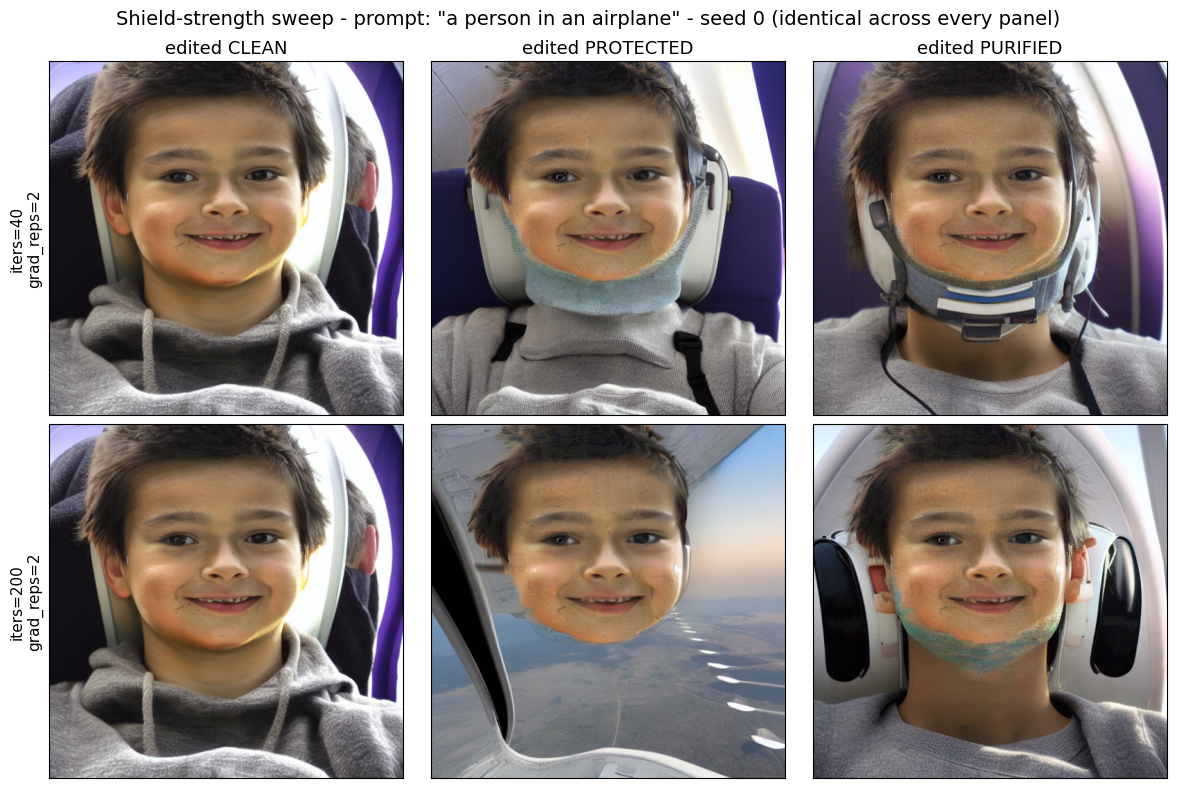

In [12]:
# 11 · The headline figure: one row per configuration, clean | protected | purified.
#      Same seed, same mask, same prompt across all three panels -- pg_generate.py re-seeds
#      numpy and torch immediately before each generation -- so every visible difference
#      is caused by the INPUT IMAGE ALONE. That is what makes this a controlled comparison.
import matplotlib.pyplot as plt
from PIL import Image

done = [c for c in CONFIGS if (ARCHIVE / tag_of(*c) / 'edit_clean').is_dir()]
assert done, 'nothing archived yet -- run cell 9 first'
name = sorted(os.listdir(ARCHIVE / tag_of(*done[0]) / 'edit_clean'))[0]

fig, axes = plt.subplots(len(done), 3, figsize=(12, 4 * len(done)), squeeze=False)
for r, (iters, reps) in enumerate(done):
    for c, (title, sub) in enumerate([('edited CLEAN', 'edit_clean'),
                                      ('edited PROTECTED', 'edit_protected'),
                                      ('edited PURIFIED', 'edit_purified')]):
        ax = axes[r][c]
        f = ARCHIVE / tag_of(iters, reps) / sub / name
        if f.exists(): ax.imshow(Image.open(f))
        ax.set_xticks([]); ax.set_yticks([])
        if r == 0: ax.set_title(title, fontsize=13)
    axes[r][0].set_ylabel(f'iters={iters}\ngrad_reps={reps}', fontsize=11)

fig.suptitle(f'Shield-strength sweep - prompt: "{PARAMS["prompt"]}" - seed {PARAMS["seed"]} '
             f'(identical across every panel)', fontsize=14)
fig.tight_layout()
fig.savefig(ARCHIVE / 'sweep_grid.png', dpi=110, bbox_inches='tight')
plt.show()

In [13]:
# 12 · VERIFY the results actually exist somewhere durable. Run this before you close the tab.
import glob as _glob

zips  = sorted(_glob.glob(str(ARCHIVE / '*.zip')))
dirs  = sorted(d for d in ARCHIVE.iterdir() if d.is_dir())
total = sum(os.path.getsize(z) for z in zips) / 1e6

print(f'ARCHIVE = {ARCHIVE}\n')
print(f'  {len(dirs)} run folder(s):', [d.name for d in dirs] or '(none)')
print(f'  {len(zips)} zip(s), {total:.1f} MB total:')
for z in zips:
    print(f'     {z}   ({os.path.getsize(z)/1e6:.1f} MB)')

if not dirs:
    print('\n!! NOTHING ARCHIVED. Cell 9 did not complete a configuration.')
elif PLATFORM == 'kaggle':
    print('\n  ON KAGGLE THESE ARE NOT YET SAFE. Do one of:')
    print('   (a) right-hand panel -> Output -> download each .zip  (fastest, do it now)')
    print('   (b) Save Version -> Save & Run All (Commit)')
    print('  Closing this session without either DISCARDS EVERYTHING above.')
elif str(ARCHIVE).startswith('/content/drive'):
    print('\n  These are on Drive already. Safe to disconnect.')
elif PLATFORM == 'colab':
    print('\n  !! These are on the EPHEMERAL VM and will be lost on disconnect.')
    print('  !! Re-run cell 1b with USE_DRIVE = True, or download the zips now:')
    print('  !!    from google.colab import files; [files.download(z) for z in zips]')
else:
    print('\n  Local disk. Nothing to do.')

ARCHIVE = /kaggle/working/tyro_results

  2 run folder(s): ['iter200_grad2_eps16', 'iter40_grad2_eps16']
  2 zip(s), 46.1 MB total:
     /kaggle/working/tyro_results/iter200_grad2_eps16.zip   (23.0 MB)
     /kaggle/working/tyro_results/iter40_grad2_eps16.zip   (23.1 MB)

  ON KAGGLE THESE ARE NOT YET SAFE. Do one of:
   (a) right-hand panel -> Output -> download each .zip  (fastest, do it now)
   (b) Save Version -> Save & Run All (Commit)
  Closing this session without either DISCARDS EVERYTHING above.


---

# Limitations

Stated plainly, because a claim we cannot evidence costs more than a modest result.

1. **Scale.** Two faces per configuration — enough for `pg_metric` to report a real standard
   deviation instead of `nan` and enough for a controlled visual comparison, but not enough
   to rank two configurations against each other. We do not attempt that ranking.
2. **How to read it at n = 2.** Never trust one metric on two images. Trust whether PSNR,
   SSIM and VIF agree on the **sign** of the recovery. Agreement means something real moved;
   disagreement means it is inside the noise — and saying so is a result.
3. **The missing grid cell.** `(200, 10)` exhausts GPU memory (repair 10). We omit it rather
   than change `diff_steps` for one point, because a grid where one point used a different
   attack is not a grid.
4. **`pg_eps` is untested.** Everything here varies `pg_iters` and `pg_grad_reps`. Both
   400-unit points landing near zero is *consistent* with `pg_iters` saturating, but equally
   consistent with both shields simply winning. This experiment cannot separate those and we
   do not claim it does.
5. **`pg_metric`'s SSIM compares the EDITED images against the EDITED CLEAN image**, not
   against the original photograph. It answers "did the editing pipeline behave normally?",
   not "is the photo intact?" `R_pipe` is built on the first question only.
6. **Why the recovery is small is an open question**, and we treat it as one. Our diagnostics
   for it are deliberately outside this notebook; they are M2 work and we quote no number
   from them here.

# What M2 adds

- ≥ 5 faces, and a **`pg_eps` sweep (16 → 24 → 32)** — the lever that raises the shield's
  ceiling, which `pg_iters` does not.
- The diagnostics: does purification move the image, does it act where the shield is, and how
  much of its effect is simply the autoencoder's own round-trip error.
- A quantitative **edit-success** rate (CLIPScore against the prompt) alongside `R_pipe`, and
  **LPIPS** alongside SSIM.
- The cheap-purifier ablation and the frequency-targeted filter, on one fidelity-vs-success
  chart.
